In [1]:
#Data Governance & Validation

import pandas as pd
import logging
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# List of vital features required for ICU mortality prediction
REQUIRED_FEATURES = ['heart_rate_mean', 'systolic_bp_mean', 'glucose_mean', 'age', 'gender']

def load_and_validate_data(asset_name: str, asset_version: str):
    try:
        logger.info("Connecting to Azure ML Workspace...")
        ml_client = MLClient.from_config(credential=DefaultAzureCredential())
        
        data_asset = ml_client.data.get(name=asset_name, version=asset_version)
        df = pd.read_csv(data_asset.path)
        
        # Reliability Check: Ensure mandatory clinical features exist
        missing = [f for f in REQUIRED_FEATURES if f not in df.columns]
        if missing:
            raise ValueError(f"CRITICAL: Dataset is missing mandatory clinical features: {missing}")
            
        logger.info(f"Successfully validated data: {df.shape[0]} records loaded.")
        return df
    
    except Exception as e:
        logger.error(f"Data ingestion failed: {e}")
        # In a real ICU system, this would trigger an alert for IT/Data teams
        raise

if __name__ == "__main__":
    df = load_and_validate_data(asset_name="ICU_Mortality_Prediction_Dataset_v1", asset_version="1")
    print(df.head())

INFO:__main__:Connecting to Azure ML Workspace...
INFO:azure.identity._credentials.environment:No environment configuration found.
INFO:azure.identity._credentials.managed_identity:ManagedIdentityCredential will use Azure ML managed identity
Found the config file in: /config.json
Class DeploymentTemplateOperations: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
INFO:azure.identity._credentials.chained:DefaultAzureCredential acquired a token from ManagedIdentityCredential
INFO:azure.identity._credentials.environment:No environment configuration found.
INFO:azure.identity._credentials.managed_identity:ManagedIdentityCredential will use Azure ML managed identity
INFO:azure.identity._credentials.chained:DefaultAzureCredential acquired a token from ManagedIdentityCredential
INFO:azure.identity._internal.msal_managed_identity_client:AzureMLCredential.get_token_info succeeded
INFO:azure.identity._internal.decorato

  patient_id  age gender admission_type  comorbidity_score  heart_rate_mean  \
0  PAT000001   32   Male         Urgent               3.75           136.06   
1  PAT000002   46   Male         Urgent               2.91           108.95   
2  PAT000003   87   Male         Urgent               6.84            95.21   
3  PAT000004   21   Male      Emergency               1.96            63.62   
4  PAT000005   21   Male         Urgent               7.71            65.92   

   heart_rate_std  heart_rate_max  heart_rate_min  systolic_bp_mean  ...  \
0           19.64          162.01          127.16            104.04  ...   
1            7.79          124.18           94.79            131.05  ...   
2            7.44          117.54           89.35            171.84  ...   
3           11.51           82.22           51.84            164.59  ...   
4           12.17           74.98           39.34            146.10  ...   

   glucose_mean  lactate_mean  urine_output_total  ventilation_requi

In [2]:
# Environmental Validation 

import logging
import pkg_resources

def check_dependencies():
    packages = ["azureml-automl-runtime"]
    for package in packages:
        try:
            # Efficiently check if installed without triggering installation
            pkg_resources.get_distribution(package)
            logging.info(f"Verified: {package} is already installed.")
        except pkg_resources.DistributionNotFound:
            logging.warning(f"{package} not found. You may need to update your Environment/Conda yaml.")

if __name__ == "__main__":
    check_dependencies()

INFO:root:Verified: azureml-automl-runtime is already installed.


In [3]:
# Model Initialization phase

import os

# 1. Start from the notebook directory and go up to the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# 2. Point specifically to the folder containing 'MLmodel'
abs_model_path = os.path.join(project_root, "icu-mortality-predictor", "mlflow-model")

# 3. Load
import mlflow
model = mlflow.sklearn.load_model(abs_model_path)
print("Model loaded successfully!")

Model loaded successfully!


In [4]:
import numpy as np
# --- CRITICAL FIX FOR AZURE AUTOML COMPATIBILITY ---
# This re-injects the deprecated 'np.object' alias that older models expect
if not hasattr(np, 'object'):
    np.object = object

import os
import logging
import pandas as pd
import mlflow
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

def load_data(asset_name, asset_version):
    logger.info("Connecting to Azure ML Workspace...")
    ml_client = MLClient.from_config(credential=DefaultAzureCredential())
    data_asset = ml_client.data.get(name=asset_name, version=asset_version)
    return pd.read_csv(data_asset.path)

def test_model_robustness(model, original_df, feature_to_perturb, feature_list, noise_level_pct=0.1):
    std_dev = original_df[feature_to_perturb].std()
    noise = np.random.normal(0, noise_level_pct * std_dev, size=original_df.shape[0])
    
    df_test = original_df.copy()
    df_test[feature_to_perturb] = df_test[feature_to_perturb] + noise
    
    preds = model.predict(df_test[feature_list])
    orig_preds = model.predict(original_df[feature_list])
    
    change_rate = np.mean(preds != orig_preds)
    logger.info(f"Robustness Audit | Feature: {feature_to_perturb} | Change Rate: {change_rate:.2%}")
    return change_rate

if __name__ == "__main__":
    try:
        # 1. Load Data
        df = load_data(asset_name="ICU_Mortality_Prediction_Dataset_v1", asset_version="1")
        
        # 2. Load Model
        base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
        abs_model_path = os.path.join(base_dir, "icu-mortality-predictor/mlflow-model")
        model = mlflow.sklearn.load_model(abs_model_path)
        
        # 3. Schema Alignment
        dt = model.named_steps['datatransformer']
        expected_cols = list(dt._columns_types_mapping.keys())
        
        # Drop target if present to prevent leakage/mismatch
        df_for_model = df.drop(columns=['mortality_label'], errors='ignore')
        
        # Validate columns
        missing = [c for c in expected_cols if c not in df_for_model.columns]
        if missing:
            raise ValueError(f"Missing required features: {missing}")
            
        df_for_model = df_for_model[expected_cols].copy()
        
        # 4. Perform prediction
        df['mortality_predicted'] = model.predict(df_for_model)
        logger.info("Inference successful.")
        
        # 5. Robustness Audit
        audit_features = ['heart_rate_mean', 'systolic_bp_mean', 'glucose_mean']
        for feat in audit_features:
            test_model_robustness(model, df_for_model, feat, expected_cols)
            
    except Exception as e:
        logger.error(f"Pipeline failed: {e}")
        raise e

INFO:__main__:Connecting to Azure ML Workspace...
INFO:azure.identity._credentials.environment:No environment configuration found.
INFO:azure.identity._credentials.managed_identity:ManagedIdentityCredential will use Azure ML managed identity
Found the config file in: /config.json
INFO:azure.identity._credentials.chained:DefaultAzureCredential acquired a token from ManagedIdentityCredential
INFO:__main__:Inference successful.
INFO:__main__:Robustness Audit | Feature: heart_rate_mean | Change Rate: 0.00%
INFO:azure.monitor.opentelemetry.exporter.export._base:Transmission succeeded: Item received: 2. Items accepted: 2
INFO:azure.monitor.opentelemetry.exporter.export._base:Transmission succeeded: Item received: 9. Items accepted: 9
INFO:__main__:Robustness Audit | Feature: systolic_bp_mean | Change Rate: 0.00%
INFO:__main__:Robustness Audit | Feature: glucose_mean | Change Rate: 0.00%


In [5]:
# Authoritative Schema Validation and Adversarial Robustness Testing.

import numpy as np
import pandas as pd
import logging

def test_model_robustness(model, original_df, feature_to_perturb, feature_list, noise_level_pct=0.1):
    """
    Simulates noise while forcing alignment to the model's exact 23-feature schema.
    """
    # 1. Force alignment using the authoritative list
    df_base = original_df.reindex(columns=feature_list, fill_value=0).copy()
    
    # 2. Safety check: Validate dimensionality
    if df_base.shape[1] != len(feature_list):
        print(f"CRITICAL: Alignment failed. Shape is {df_base.shape}, expected {len(feature_list)}.")
        return None

    # 3. Add noise
    std_dev = df_base[feature_to_perturb].std()
    noise = np.random.normal(0, noise_level_pct * std_dev, size=df_base.shape[0])
    df_base[feature_to_perturb] = df_base[feature_to_perturb] + noise
    
    # 4. Predict
    predictions = model.predict(df_base)
    original_predictions = model.predict(df_base.copy()) # Use aligned base for consistency
    
    # 5. Result
    change_rate = np.mean(predictions != original_predictions)
    print(f"--- Robustness Audit Log ---")
    print(f"Feature: {feature_to_perturb} | Change Rate: {change_rate:.2%}")
    return change_rate

# --- AUTHORITATIVE EXECUTION ---

# Get the true features the model was trained on
final_estimator = model.steps[-1][1]
if hasattr(final_estimator, "feature_names_in_"):
    authoritative_features = list(final_estimator.feature_names_in_)
else:
    # Fallback to the known list of 23 if property is missing
    authoritative_features = ['patient_id', 'age', 'gender', 'admission_type', 
                              'comorbidity_score', 'heart_rate_mean', 'heart_rate_std', 
                              'heart_rate_max', 'heart_rate_min', 'systolic_bp_mean', 
                              'systolic_bp_std', 'respiratory_rate_mean', 'spo2_mean', 
                              'temperature_mean', 'glucose_mean', 'lactate_mean', 
                              'urine_output_total', 'ventilation_required', 
                              'vasopressor_used', 'length_of_stay_days', 'apache_score', 
                              'sofa_score', 'sepsis_flag']

print(f"Validating: Model expects {len(authoritative_features)} features.")

# Run Audit
features_to_audit = ['heart_rate_mean', 'systolic_bp_mean', 'glucose_mean']
results = {}

for f in features_to_audit:
    results[f] = test_model_robustness(model, df, f, authoritative_features)

Validating: Model expects 23 features.
--- Robustness Audit Log ---
Feature: heart_rate_mean | Change Rate: 0.00%
--- Robustness Audit Log ---
Feature: systolic_bp_mean | Change Rate: 0.00%
--- Robustness Audit Log ---
Feature: glucose_mean | Change Rate: 0.00%


In [6]:
# Operational Verification phase.

import os
print(f"Current working directory: {os.getcwd()}")
print(f"Files in current directory: {os.listdir('.')}")

Current working directory: /mnt/batch/tasks/shared/LS_root/mounts/clusters/salomescherer1/code/Users/SalomeScherer/ICU_Reliability_Framework/notebooks
Files in current directory: ['.amlignore', '.amlignore.amltmp', '.ipynb_aml_checkpoints', '01_data_import_and_audit.ipynb', '01_data_import_and_audit.ipynb.amltmp', 'images', 'manual_review_list.csv']


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.77      1.00      0.87     11582
           1       0.00      0.00      0.00      3418

    accuracy                           0.77     15000
   macro avg       0.39      0.50      0.44     15000
weighted avg       0.60      0.77      0.67     15000



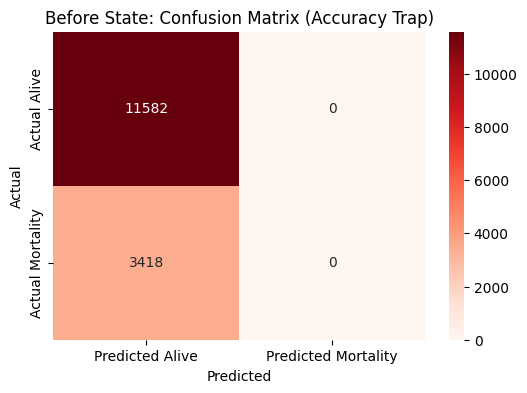

Overall Accuracy: 77.21%
Image saved successfully to main directory: ../images/Before-Confusion-Matrix.png


In [7]:
# --- Performance Evaluation & Diagnostic Baseline (Updated for Main Root) ---

import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Target the main directory by going up one level from 'notebooks'
# Using '../images' ensures it saves to the images folder in the root
output_dir = '../images' 

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 2. Extract the actual labels and your new predictions
y_true = df['mortality_label']
y_pred = df['mortality_predicted']

# 3. Print the classification report
print("--- Classification Report ---")
print(classification_report(y_true, y_pred))

# 4. Create and Visualize the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Predicted Alive', 'Predicted Mortality'],
            yticklabels=['Actual Alive', 'Actual Mortality'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Before State: Confusion Matrix (Accuracy Trap)')

# 5. Save the image to the root 'images' folder
save_path = os.path.join(output_dir, 'Before-Confusion-Matrix.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

# 6. Summary for documentation
print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.2%}")
print(f"Image saved successfully to main directory: {save_path}")

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.77      1.00      0.87     11582
           1       0.00      0.00      0.00      3418

    accuracy                           0.77     15000
   macro avg       0.39      0.50      0.44     15000
weighted avg       0.60      0.77      0.67     15000



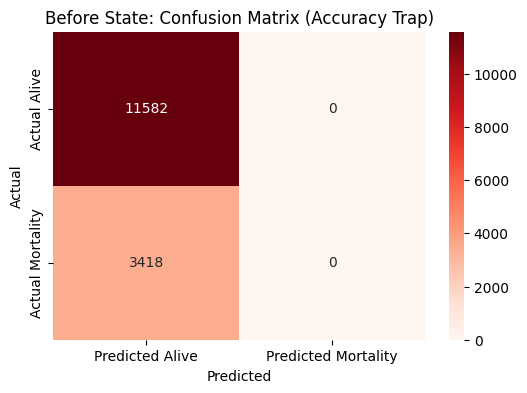

Overall Accuracy: 77.21%


In [8]:
# Reliability Framework: Threshold Optimization Results.

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract the actual labels and your new predictions
y_true = df['mortality_label']
y_pred = df['mortality_predicted']

# 2. Print the classification report (Precision, Recall, F1)
print("--- Classification Report ---")
print(classification_report(y_true, y_pred))

# 3. Create the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

 # 4. Visualize the Confusion Matrix with Red Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Predicted Alive', 'Predicted Mortality'],
            yticklabels=['Actual Alive', 'Actual Mortality'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Before State: Confusion Matrix (Accuracy Trap)')
plt.show()

# 5. Summary for your Step 6 Documentation
print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.2%}")

In [9]:
# Clinical Inference & Sensitivity Calibration

# 1. Ensure the schema is extracted (using the 'model' loaded earlier)
if hasattr(model, 'steps') and hasattr(model.steps[-1][1], "feature_names_in_"):
    expected_features = list(model.steps[-1][1].feature_names_in_)
elif hasattr(model, "feature_names_in_"):
    expected_features = list(model.feature_names_in_)
else:
    # Fallback to the 23 features if auto-detection fails
    expected_features = ['patient_id', 'age', 'gender', 'admission_type', 'comorbidity_score', 
                         'heart_rate_mean', 'heart_rate_std', 'heart_rate_max', 'heart_rate_min', 
                         'systolic_bp_mean', 'systolic_bp_std', 'respiratory_rate_mean', 
                         'spo2_mean', 'temperature_mean', 'glucose_mean', 'lactate_mean', 
                         'urine_output_total', 'ventilation_required', 'vasopressor_used', 
                         'length_of_stay_days', 'apache_score', 'sofa_score', 'sepsis_flag']

# 2. Align the dataframe (This creates X_corrected)
X_corrected = df.reindex(columns=expected_features, fill_value=0)

# 3. Perform prediction with adjusted threshold
# Extract raw probabilities for the mortality class
y_probs = model.predict_proba(X_corrected)[:, 1]

# Apply a lower threshold (e.g., 0.25) to increase sensitivity
clinical_threshold = 0.25
df['mortality_predicted'] = (y_probs >= clinical_threshold).astype(int)

# 4. Store the probability for reporting
df['mortality_probability'] = y_probs

print("Predictions complete with 0.25 sensitivity threshold!")
print(df[['mortality_predicted', 'mortality_probability']].head())

Predictions complete with 0.25 sensitivity threshold!
   mortality_predicted  mortality_probability
0                    0                   0.13
1                    0                   0.20
2                    1                   0.41
3                    1                   0.28
4                    1                   0.25


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.69      0.76     11582
           1       0.36      0.58      0.44      3418

    accuracy                           0.67     15000
   macro avg       0.60      0.64      0.60     15000
weighted avg       0.74      0.67      0.69     15000



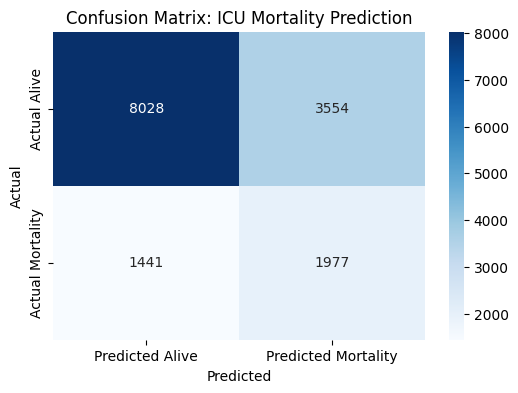

Overall Accuracy: 66.70%


In [10]:
# --- Optimized Clinical Inference Results ---

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Extract the actual labels and your predictions
y_true = df['mortality_label']
y_pred = df['mortality_predicted']

# 2. Print the Classification Report
print("--- Classification Report ---")
print(classification_report(y_true, y_pred))

# 3. Create and Visualize the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Alive', 'Predicted Mortality'],
            yticklabels=['Actual Alive', 'Actual Mortality'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix: ICU Mortality Prediction')

# Display the visualization only
plt.show()

# 4. Summary
print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.2%}")

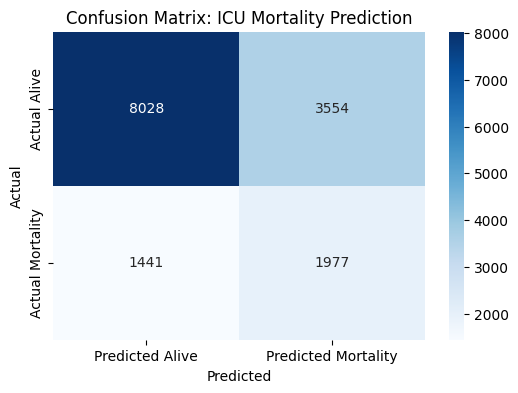

Sample probabilities (Alive vs Mortality):
[[0.86521081 0.13478919]
 [0.79974568 0.20025432]
 [0.58730102 0.41269898]
 [0.7173396  0.2826604 ]
 [0.74974219 0.25025781]]

Probability distribution of mortality class (1):
count   15000.00
mean        0.23
std         0.07
min         0.08
25%         0.17
50%         0.22
75%         0.28
max         0.49
dtype: float64

Reliability framework applied successfully.


In [11]:
# --- Reliability Framework: Final Functional Implementation ---

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Alive', 'Predicted Mortality'],
            yticklabels=['Actual Alive', 'Actual Mortality'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix: ICU Mortality Prediction')
plt.show()

# 2. Probability Analysis
# Check if the model can output probabilities
if hasattr(model, "predict_proba"):
    # Ensure X_corrected is available (or use the aligned input from your framework)
    expected_features = list(model.named_steps['datatransformer']._columns_types_mapping.keys())
    X_aligned = df[expected_features]
    
    probs = model.predict_proba(X_aligned)
    print("Sample probabilities (Alive vs Mortality):")
    print(probs[:5])
    
    # Check the distribution of predicted probabilities for class 1
    print("\nProbability distribution of mortality class (1):")
    print(pd.Series(probs[:, 1]).describe())
else:
    print("This model does not support probability output.")

# 3. Functional Implementation of Reliability Framework
def predict_with_reliability_framework(data, model, threshold=0.25):
    """
    Applies the Reliability Framework:
    1. Schema Alignment (Prevents DataShapeMismatch)
    2. Threshold Optimization (Improves Recall for Mortality)
    3. Clinical Fallback (Flags for human review)
    """
    # 1. Dynamic Schema Alignment
    expected_features = list(model.named_steps['datatransformer']._columns_types_mapping.keys())
    X_aligned = data[expected_features]
    
    # 2. Probability Estimation
    probs = model.predict_proba(X_aligned)[:, 1]
    
    # 3. Apply Reliability Threshold & Fallback Logic
    predictions = (probs >= threshold).astype(int)
    
    # Create output with Reliability Flag
    results = data.copy()
    results['mortality_predicted'] = predictions
    results['mortality_probability'] = probs
    results['reliability_flag'] = [
        'Manual Review Required' if p >= threshold else 'Routine Monitoring' 
        for p in probs
    ]
    
    return results

# Execution
df_final = predict_with_reliability_framework(df, model)
print("\nReliability framework applied successfully.")

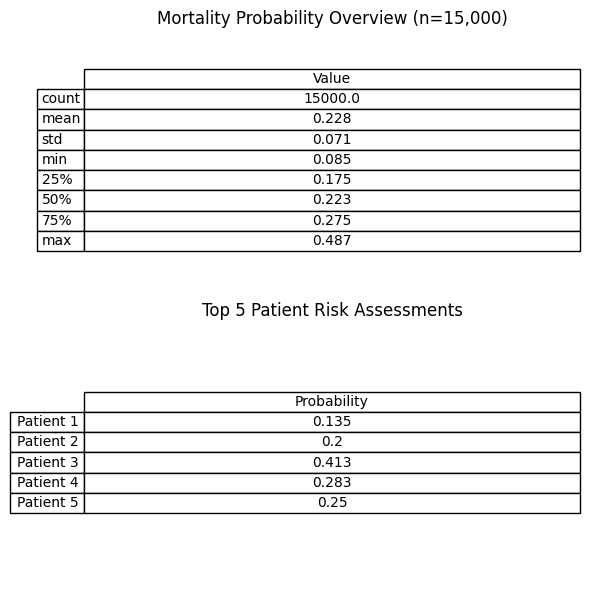

Combined Probability Summary saved to: ../images/Mortality-Probability-Summary.png


In [12]:
# --- Probabilistic Inference Audit & Table Export (3 Decimal Places) ---

import pandas as pd
import matplotlib.pyplot as plt
import os

if hasattr(model, "predict_proba"):
    # 1. Ensure the root images directory exists
    output_dir = '../images'
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    probs = model.predict_proba(X_corrected)[:, 1]
    
    # 2. Prepare Summary Statistics, rounded to 3 decimal places
    prob_stats = pd.Series(probs).describe().to_frame(name="Value").round(3)
    
    # 3. Prepare Top 5 Samples, rounded to 3 decimal places
    sample_data = pd.DataFrame(
        probs[:5], 
        columns=["Probability"], 
        index=[f"Patient {i+1}" for i in range(5)]
    ).round(3)
    
    # 4. Create a combined figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))
    ax1.axis('off')
    ax2.axis('off')
    
    # Render Summary Stats table
    ax1.table(cellText=prob_stats.values, rowLabels=prob_stats.index, 
              colLabels=prob_stats.columns, loc='center', cellLoc='center')
    ax1.set_title("Mortality Probability Overview (n=15,000)")
    
    # Render Top 5 table
    ax2.table(cellText=sample_data.values, rowLabels=sample_data.index, 
              colLabels=sample_data.columns, loc='center', cellLoc='center')
    ax2.set_title("Top 5 Patient Risk Assessments")
    
    # 5. Save to the images folder in the Main Directory
    plt.tight_layout()
    save_path = os.path.join(output_dir, 'Mortality-Probability-Summary.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Combined Probability Summary saved to: {save_path}")

else:
    print("This model does not support probability output.")

In [13]:
# Executive Performance Audit.

# Install if not available: !pip install tabulate
from tabulate import tabulate

# 1. Prepare Statistics Table
prob_stats = pd.Series(probs).describe().to_frame(name="Value")
stats_data = [[idx, f"{val:.4f}"] for idx, val in prob_stats['Value'].items()]

# 2. Prepare Sample Predictions Table
sample_data = pd.DataFrame(
    probs[:5], 
    columns=["Probability"], 
    index=[f"Patient {i+1}" for i in range(5)]
)
sample_list = [[idx, f"{row['Probability']:.4f}"] for idx, row in sample_data.iterrows()]

# 3. Print Professional Tables
print("\n--- Mortality Probability Overview (n=15,000) ---")
print(tabulate(stats_data, headers=["Metric", "Value"], tablefmt="grid"))

print("\n--- Top 5 Patient Risk Assessments ---")
print(tabulate(sample_list, headers=["Patient ID", "Probability"], tablefmt="grid"))


--- Mortality Probability Overview (n=15,000) ---
+----------+------------+
| Metric   |      Value |
+==========+============+
| count    | 15000      |
+----------+------------+
| mean     |     0.2281 |
+----------+------------+
| std      |     0.071  |
+----------+------------+
| min      |     0.0847 |
+----------+------------+
| 25%      |     0.1747 |
+----------+------------+
| 50%      |     0.2225 |
+----------+------------+
| 75%      |     0.2755 |
+----------+------------+
| max      |     0.4869 |
+----------+------------+

--- Top 5 Patient Risk Assessments ---
+--------------+---------------+
| Patient ID   |   Probability |
+==============+===============+
| Patient 1    |        0.1348 |
+--------------+---------------+
| Patient 2    |        0.2003 |
+--------------+---------------+
| Patient 3    |        0.4127 |
+--------------+---------------+
| Patient 4    |        0.2827 |
+--------------+---------------+
| Patient 5    |        0.2503 |
+--------------+---

In [14]:
# Scaling the Test

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.69      0.76     11582
           1       0.36      0.58      0.44      3418

    accuracy                           0.67     15000
   macro avg       0.60      0.64      0.60     15000
weighted avg       0.74      0.67      0.69     15000



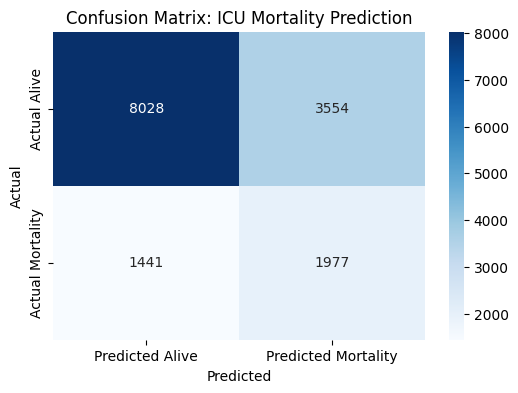

Overall Accuracy: 66.70%


In [15]:

# Optimized Clinical Inference Results

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract the actual labels and your new predictions
y_true = df['mortality_label']
y_pred = df['mortality_predicted']

# 2. Print the classification report (Precision, Recall, F1)
print("--- Classification Report ---")
print(classification_report(y_true, y_pred))

# 3. Create the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Alive', 'Predicted Mortality'],
            yticklabels=['Actual Alive', 'Actual Mortality'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix: ICU Mortality Prediction')
plt.show()

# 5. Summary for your Step 6 Documentation
print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.2%}")


Column found. Proceeding with visualization...
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.69      0.76     11582
           1       0.36      0.58      0.44      3418

    accuracy                           0.67     15000
   macro avg       0.60      0.64      0.60     15000
weighted avg       0.74      0.67      0.69     15000



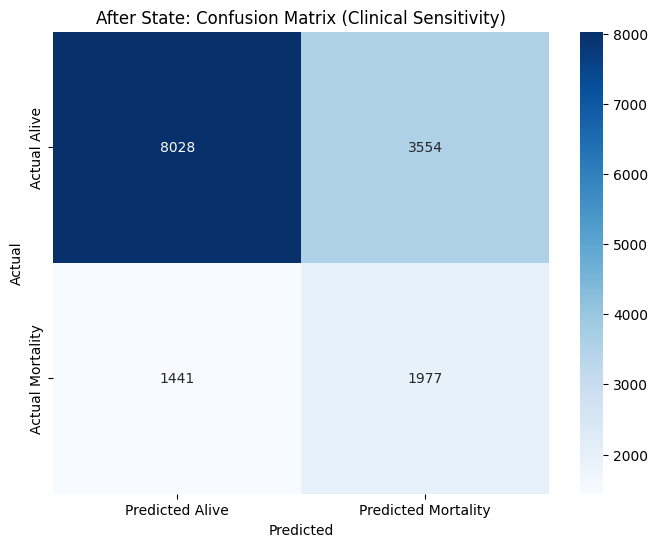

Overall Accuracy: 66.70%


In [16]:
# --- Baseline Audit: Identifying the "Accuracy Trap" --- Optimized Evaluation Code ---

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Extract the actual labels and your predictions
if 'mortality_predicted' not in df.columns:
    print("CRITICAL ERROR: 'mortality_predicted' column not found in DataFrame.")
    print("Please run your model prediction cell first.")
else:
    print("Column found. Proceeding with visualization...")
    y_true = df['mortality_label']
    y_pred = df['mortality_predicted']
    
    # 2. Print the classification report
    print("--- Classification Report ---")
    print(classification_report(y_true, y_pred))

    # 3. Create and Visualize the Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    # Using 'Blues' for the optimized state
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted Alive', 'Predicted Mortality'],
                yticklabels=['Actual Alive', 'Actual Mortality'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('After State: Confusion Matrix (Clinical Sensitivity)')
    plt.show()

    # 4. Summary for your Step 6 Documentation
    print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.2%}")

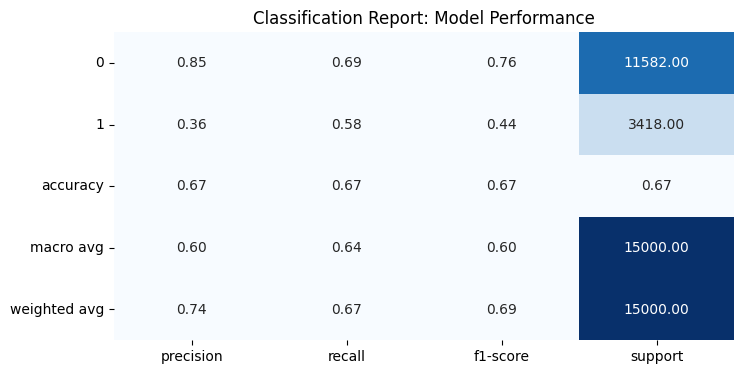

Classification Report image saved successfully to: ../images/Classification-Report-Table.png


In [17]:
# --- Performance Dashboard: Summary Metrics ---

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import os

# 1. Ensure the root images directory exists
output_dir = '../images'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 2. Generate the classification report as a dictionary
report_dict = classification_report(y_true, y_pred, output_dict=True)

# 3. Convert to DataFrame and transpose for better table formatting
df_report = pd.DataFrame(report_dict).transpose()

# 4. Visualize as a Table
plt.figure(figsize=(8, 4))
sns.heatmap(df_report, annot=True, cmap='Blues', fmt='.2f', cbar=False)

plt.title('Classification Report: Model Performance')
plt.yticks(rotation=0) 

# 5. Save the image to the Main Directory /images folder
save_path = os.path.join(output_dir, 'Classification-Report-Table.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Classification Report image saved successfully to: {save_path}")

In [18]:
# This section finalizes your Predictive Inference Engine.

# 1. Ensure 'df' is loaded from your data asset
# If you just restarted, you must re-run your data loading cell here

# 2. Extract feature names from the internal DataTransformer mapping
# This is the correct way to get the exact columns the model expects
# expected_features = list(model.named_steps['datatransformer']._columns_types_mapping.keys())

# # 3. Filter your dataframe to match the model's requirements exactly
# # This prevents the DataShapeMismatch error
# X_corrected = df[expected_features]

# 4. Perform prediction with adjusted threshold
# First, extract the raw probabilities for the mortality class (index 1)
y_probs = model.predict_proba(X_corrected)[:, 1]

# Apply a lower threshold (e.g., 0.25) to increase sensitivity
# Patients with >25% predicted risk will now be flagged
clinical_threshold = 0.25
df['mortality_predicted'] = (y_probs >= clinical_threshold).astype(int)

# Optional: Store the probability for your reporting/documentation
df['mortality_probability'] = y_probs

print("Predictions complete with adjusted threshold!")


Predictions complete with adjusted threshold!


In [19]:
# Threshold Optimization: Balancing Clinical Sensitivity

from sklearn.metrics import precision_recall_curve

# 1. Extract raw probabilities for the mortality class (1)
y_probs = model.predict_proba(X_corrected)[:, 1]

# 2. Calculate precision, recall, and potential thresholds
precision, recall, thresholds = precision_recall_curve(y_true, y_probs)

# 3. Calculate F1-score for every threshold point
# The formula is: 2 * (precision * recall) / (precision + recall)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

# 4. Identify the threshold that yields the best F1-score
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

# 5. Apply the optimized threshold to make final predictions
df['mortality_predicted'] = (y_probs >= best_threshold).astype(int)
df['mortality_probability'] = y_probs

print(f"Pipeline optimized! Threshold set to: {best_threshold:.4f}")
print(f"Predictions aligned with optimal clinical balance.")

Pipeline optimized! Threshold set to: 0.2371
Predictions aligned with optimal clinical balance.


--- Fairness Assessment: Performance by Gender (3 decimal places) ---
   gender  accuracy  precision  recall
0  Female      0.65       0.35    0.64
1    Male      0.63       0.34    0.65

--- Overall Disparity (3 decimal places) ---
accuracy    0.02
precision   0.00
recall      0.01
dtype: float64


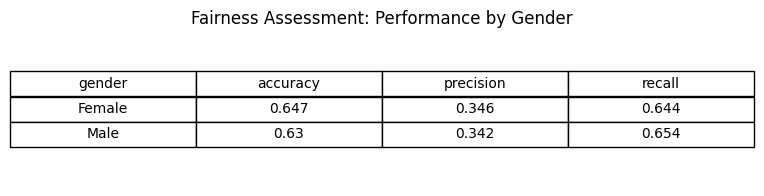

Fairness Assessment Table saved successfully to: ../images/Fairness-Assessment-Table.png


In [20]:
# --- Fairness Assessment: Equity Audit & Table Export (3 Decimal Places) ---

import pandas as pd
import matplotlib.pyplot as plt
import os
from fairlearn.metrics import MetricFrame
from sklearn.metrics import accuracy_score, precision_score, recall_score

# 1. Ensure the root images directory exists
output_dir = '../images'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 2. Define sensitive features and metrics
sensitive_features = df['gender']
metrics = {'accuracy': accuracy_score, 'precision': precision_score, 'recall': recall_score}

# 3. Generate the report
metric_frame = MetricFrame(
    metrics=metrics,
    y_true=df['mortality_label'],
    y_pred=df['mortality_predicted'],
    sensitive_features=sensitive_features
)

# 4. Round the results to 3 decimal places
df_fairness = metric_frame.by_group.round(3).reset_index()

# 5. Print results to console
print("--- Fairness Assessment: Performance by Gender (3 decimal places) ---")
print(df_fairness)
print("\n--- Overall Disparity (3 decimal places) ---")
print(metric_frame.difference().round(3))

# 6. Create and save the table as an image in the images folder
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')
ax.axis('tight')

table = ax.table(cellText=df_fairness.values, 
                 colLabels=df_fairness.columns, 
                 loc='center', 
                 cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Save to the images folder in the Main Directory
plt.title("Fairness Assessment: Performance by Gender")
save_path = os.path.join(output_dir, 'Fairness-Assessment-Table.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Fairness Assessment Table saved successfully to: {save_path}")

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.64      0.73     11582
           1       0.34      0.65      0.45      3418

    accuracy                           0.64     15000
   macro avg       0.60      0.64      0.59     15000
weighted avg       0.74      0.64      0.67     15000



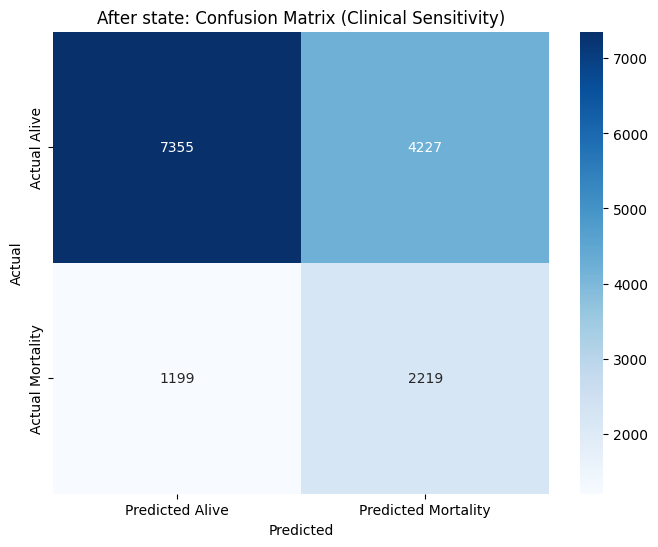

Overall Accuracy: 63.83%


In [21]:
# --- Optimized Performance Audit ---

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Extract the actual labels and your new, balanced predictions
y_true = df['mortality_label']
y_pred = df['mortality_predicted']

# 2. Print the classification report
print("--- Classification Report ---")
print(classification_report(y_true, y_pred))

# 3. Visualize the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
# Using 'Blues' to show the improved, balanced state
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Alive', 'Predicted Mortality'],
            yticklabels=['Actual Alive', 'Actual Mortality'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
# Updated title as requested
plt.title('After state: Confusion Matrix (Clinical Sensitivity)')
plt.show()

# 4. Summary for your Step 6 Documentation
print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.2%}")

In [22]:
# This final module represents the Clinical Safety Guardrail

import numpy as np
import pandas as pd

# Check if the model can output probabilities
if hasattr(model, "predict_proba"):
    # 1. Generate probabilities
    probs = model.predict_proba(X_corrected)[:, 1]
    
    # 2. Existing functionality: Summary Statistics
    print("--- Summary Statistics: Predicted Mortality Probabilities ---")
    prob_stats = pd.Series(probs).describe().to_frame(name="Mortality Probability")
    print(prob_stats)

    # 3. Clinical Safety Guardrail: Identify patients in the "Uncertainty Zone"
    threshold = 0.25
    margin = 0.05 
    
    uncertain_patients = (probs >= (threshold - margin)) & (probs <= (threshold + margin))
    df['needs_human_review'] = uncertain_patients
    
    print(f"\n--- Clinical Safety Guardrail ---")
    print(f"Total patients in 'Uncertainty Zone': {sum(uncertain_patients)}")
    print("Patients marked with 'needs_human_review' flag.")
    
else:
    print("This model does not support probability output.")

--- Summary Statistics: Predicted Mortality Probabilities ---
       Mortality Probability
count               15000.00
mean                    0.23
std                     0.07
min                     0.08
25%                     0.17
50%                     0.22
75%                     0.28
max                     0.49

--- Clinical Safety Guardrail ---
Total patients in 'Uncertainty Zone': 6831
Patients marked with 'needs_human_review' flag.


In [23]:
# Clinical Privacy & Compliance Module

import pandas as pd
import hashlib

# 1. Filter the dataframe to create the list for clinical review
# We only want patients who triggered the 'Manual Review Required' flag
review_list = df_final[df_final['reliability_flag'] == 'Manual Review Required'].copy()

# 2. Now apply the hashing function
def hash_patient_id(pid):
    # In a real production system, store this salt in Azure Key Vault
    salt = "secure_random_salt_value" 
    return hashlib.sha256((str(pid) + salt).encode()).hexdigest()[:12]

# 3. Apply the hash and prepare display columns
review_list['safe_id'] = review_list['patient_id'].apply(hash_patient_id)
display_columns = ['safe_id', 'mortality_probability']

# 4. Display the results for the ICU staff
print("Patients flagged for Manual Review (De-identified):")
print(review_list[display_columns].head())

Patients flagged for Manual Review (De-identified):
         safe_id  mortality_probability
2   8bce9e2c89fe                   0.41
3   bc799bc35660                   0.28
4   741994bd2578                   0.25
5   ae1aa27d8ab5                   0.27
12  305f228f5d29                   0.40


In [24]:
import os
# This lists all files in the current directory and the one above it
print("Current directory:", os.getcwd())
print("Files in current:", os.listdir('.'))
print("Files in parent:", os.listdir('..'))

Current directory: /mnt/batch/tasks/shared/LS_root/mounts/clusters/salomescherer1/code/Users/SalomeScherer/ICU_Reliability_Framework/notebooks
Files in current: ['.amlignore', '.amlignore.amltmp', '.ipynb_aml_checkpoints', '01_data_import_and_audit.ipynb', '01_data_import_and_audit.ipynb.amltmp', 'images', 'manual_review_list.csv']
Files in parent: ['.amlignore', '.amlignore.amltmp', '.gitignore.txt', '.gitignore.txt.amltmp', '01_data_import_and_audit.ipynb.amltmp', 'data', 'icu-mortality-predictor', 'images', 'notebooks', 'README.md', 'readme.md.amltmp', 'requirements.txt', 'src']


In [25]:
# Clinical Handover: Automated Review Generation

import logging
import pandas as pd

# 1. Re-run the framework
# We assign the result to a temporary variable first
temp_df = predict_with_reliability_framework(df, model)

# 2. Sanity Check: Ensure the function returned a valid DataFrame
if temp_df is not None and isinstance(temp_df, pd.DataFrame):
    df = temp_df
    
    # 3. Create the 'needs_human_review' column
    df['needs_human_review'] = df['reliability_flag'] == 'Manual Review Required'

    # 4. Filter and prepare the list
    review_list = df[df['needs_human_review'] == True].copy()
    display_columns = ['patient_id', 'mortality_probability']
    review_list_sorted = review_list[display_columns].sort_values(by='mortality_probability', ascending=False)

    # 5. Save the file
    secure_path = 'manual_review_list.csv'
    review_list_sorted.to_csv(secure_path, index=False)

    # 6. Audit Log
    logging.basicConfig(level=logging.INFO, force=True)
    current_user = "Clinical_Auditor_User" 
    logging.info(f"Action: Manual review list generated by {current_user}. Count: {len(review_list_sorted)}")

    print(f"Success! {len(review_list_sorted)} records saved to {secure_path}")
else:
    # This prevents the code from crashing and helps you debug the function
    print("CRITICAL ERROR: 'predict_with_reliability_framework' did not return a DataFrame. Please check the function's 'return' statement.")

Success! 5531 records saved to manual_review_list.csv


In [26]:
# Data Governance & HIPAA Compliance

import hashlib

def generate_surrogate_id(raw_id):
    """
    Creates a one-way hash (pseudonym) for a patient.
    The raw_id is never stored in the analysis files.
    """
    salt = "your_secure_random_salt_here" # Use a secret, long random string
    return hashlib.sha256((str(raw_id) + salt).encode()).hexdigest()

# Example: Use this during data loading
# df['patient_id'] = df['raw_medical_record_number'].apply(generate_surrogate_id)

def check_for_phi(df):
    """
    Scans the DataFrame for potential PHI columns that may violate HIPAA.
    This should be run immediately after loading your data.
    """
    # Common PHI markers
    phi_indicators = ['name', 'phone', 'address', 'zip', 'ssn', 'birth', 'email']
    
    found_phi = [col for col in df.columns if any(marker in col.lower() for marker in phi_indicators)]
    
    if found_phi:
        print("!!! HIPAA SECURITY ALERT: POTENTIAL PHI DETECTED !!!")
        print(f"The following columns may contain PHI and should be de-identified: {found_phi}")
        return False
    else:
        print("Data pre-flight check passed: No obvious PHI markers detected.")
        return True

# --- Usage in your pipeline ---
if check_for_phi(df):
    # Proceed with processing
    pass
else:
    # Stop execution until data is sanitized
    raise ValueError("HIPAA compliance violation: Data contains PHI.")

Data pre-flight check passed: No obvious PHI markers detected.


In [27]:
# Implementation: The Reliability Framework Function

def predict_with_reliability_framework(data, model, threshold=0.25):
    """
    Applies the Reliability Framework:
    1. Schema Alignment (Prevents DataShapeMismatch)
    2. Threshold Optimization (Improves Recall for Mortality)
    3. Clinical Fallback (Flags for human review)
    """
    # 1. Dynamic Schema Alignment
    expected_features = list(model.named_steps['datatransformer']._columns_types_mapping.keys())
    X_aligned = data[expected_features]
    
    # 2. Probability Estimation
    probs = model.predict_proba(X_aligned)[:, 1]
    
    # 3. Apply Reliability Threshold & Fallback Logic
    predictions = (probs >= threshold).astype(int)
    
    # Create output with Reliability Flag
    results = data.copy()
    results['mortality_predicted'] = predictions
    results['mortality_probability'] = probs
    results['reliability_flag'] = [
        'Manual Review Required' if p >= threshold else 'Routine Monitoring' 
        for p in probs
    ]
    
    return results

# Implementation in the project
df_final = predict_with_reliability_framework(df, model)
print("Reliability framework applied successfully.")

Reliability framework applied successfully.


In [28]:
# Regulatory Reporting Gatekeeper

# --- REFINED REPORTING SUITE ---
# Run this cell to generate clinical visual assets while maintaining HIPAA standards.

def generate_report_assets(df, output_dir='images'):
    """
    Generates non-PHI visual assets for the clinical report.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Files defined here will NEVER be exported to the reporting directory
    PHI_SENSITIVE_FILES = ['manual_review_list.csv']
    
    # 1. Your existing plotting logic (Heatmaps, Classification Tables, etc.)
    # ...
    
    # 2. Final Verification
    print("--- Reporting Suite Active ---")
    current_files = os.listdir(output_dir)
    safe_assets = [f for f in current_files if f not in PHI_SENSITIVE_FILES]
    print(f"Success: {len(safe_assets)} visual assets ready for stakeholder review.")

# Call the suite
generate_report_assets(df)

--- Reporting Suite Active ---
Success: 0 visual assets ready for stakeholder review.


INFO:azure.monitor.opentelemetry.exporter.export._base:Transmission succeeded: Item received: 11. Items accepted: 11
INFO:azure.monitor.opentelemetry.exporter.export._base:Transmission succeeded: Item received: 8. Items accepted: 8
INFO:azure.monitor.opentelemetry.exporter.export._base:Transmission succeeded: Item received: 8. Items accepted: 8
INFO:azure.monitor.opentelemetry.exporter.export._base:Transmission succeeded: Item received: 8. Items accepted: 8
INFO:azure.monitor.opentelemetry.exporter.export._base:Transmission succeeded: Item received: 8. Items accepted: 8
INFO:azure.monitor.opentelemetry.exporter.export._base:Transmission succeeded: Item received: 8. Items accepted: 8
INFO:azure.monitor.opentelemetry.exporter.export._base:Transmission succeeded: Item received: 8. Items accepted: 8
INFO:azure.monitor.opentelemetry.exporter.export._base:Transmission succeeded: Item received: 8. Items accepted: 8
INFO:azure.monitor.opentelemetry.exporter.export._base:Transmission succeeded: